# Stage 3: Causal Disentanglement

**Objective:** Establish *causal* (not merely correlational) evidence that gender-correlated shortcut features mediate the path from gender to model predictions. Move beyond "the model encodes shortcuts" (Stage 2) to "the model *causally relies* on shortcuts, and this reliance is gender-biased."

**Methods:**
1. **Structural Causal Model (SCM):** Formalize the DAG linking gender, shortcuts, clinical signal, embeddings, and predictions
2. **Causal Mediation Analysis:** Estimate what fraction of the gender→prediction association flows through each shortcut (ACME, ADE, proportion mediated)
3. **Concept Erasure (INLP):** Remove shortcut information from [CLS] embeddings via Iterative Nullspace Projection, then re-probe for gender and label
4. **Counterfactual Interventions:** Apply a fixed label classifier to shortcut-erased embeddings; measure prediction flip rates stratified by gender
5. **Conditional Independence Tests:** Test whether gender provides information about labels beyond what shortcuts already capture

**Inputs:** `data/stage1/features_18_extracted.pkl`, frozen DistilRoBERTa [CLS] embeddings (768-d, cached from Stage 2)

**Shortcut candidates (6, from Stage 1 MI analysis):**
`fp_singular`, `emotional_feeling`, `excl_intensifiers`, `hedge_density`, `post_length`, `question_density`

**Control features (4):** `absolutist`, `past_tense`, `negation`, `cognitive_processing`

In [1]:
import os, warnings, time
warnings.filterwarnings('ignore')
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
from scipy.special import expit
from scipy.stats import chi2
from transformers import AutoTokenizer, AutoModel

sns.set_style('whitegrid')
plt.rcParams.update({'font.size': 11})

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
N_GPUS = torch.cuda.device_count() if DEVICE == 'cuda' else 0
print(f'Device: {DEVICE}  |  GPUs: {N_GPUS}')

# ── 6 MI-flagged shortcut candidates (18-feature analysis) ───────────────────
SHORTCUT_FEATURES = [
    'fp_singular', 'emotional_feeling', 'excl_intensifiers',
    'hedge_density', 'post_length', 'question_density',
]
ALL_18_FEATURES = [
    'hedge_density', 'fp_singular', 'fp_plural', 'emotional_feeling',
    'social_relational', 'certainty', 'negative_emotion', 'swear_words',
    'excl_intensifiers', 'question_density', 'post_length', 'apology_selfblame',
    'anger', 'body_health',
    'absolutist', 'past_tense', 'negation', 'cognitive_processing',
]
CONTROL_FEATURES = ['absolutist', 'past_tense', 'negation', 'cognitive_processing']

SEED = 42
N_BOOT = 1000
np.random.seed(SEED)
print(f'Shortcut features ({len(SHORTCUT_FEATURES)}): {SHORTCUT_FEATURES}')
print(f'Control features ({len(CONTROL_FEATURES)}): {CONTROL_FEATURES}')
print(f'All features: {len(ALL_18_FEATURES)}')
print(f'Bootstrap iterations: {N_BOOT}')

Device: cpu  |  GPUs: 0
Shortcut features (6): ['fp_singular', 'emotional_feeling', 'excl_intensifiers', 'hedge_density', 'post_length', 'question_density']
Control features (4): ['absolutist', 'past_tense', 'negation', 'cognitive_processing']
All features: 18
Bootstrap iterations: 1000


In [2]:
# -- Load Stage 1/2 data ---------------------------------------------------
df = pd.read_pickle('data/stage1/features_18_extracted.pkl')
df['text'] = df['text'].fillna('')
GENDER_COL = 'gender_label' if 'gender_label' in df.columns else 'gender'
df['gender_bin'] = (df[GENDER_COL] == 'female').astype(int)

print(f'Total rows: {len(df):,}')
print(f'Gender: {df[GENDER_COL].value_counts().to_dict()}')
print(f'Labels: {df["binary_label"].value_counts().to_dict()}')

# -- [CLS] embeddings (cached from Stage 2) --------------------------------
CLS_CACHE = 'data/stage2/cls_embeddings.npy'
X_cls_all = np.load(CLS_CACHE)
print(f'\nLoaded cached [CLS]: {X_cls_all.shape}')
assert len(X_cls_all) == len(df), f'Shape mismatch: {len(X_cls_all)} vs {len(df)}'
print('Shape check passed.')

Total rows: 32,200
Gender: {'female': 16100, 'male': 16100}
Labels: {0: 22601, 1: 9599}

Loaded cached [CLS]: (32200, 768)
Shape check passed.


## Part A — Structural Causal Model

We formalize the causal relationships as a Directed Acyclic Graph (DAG). The key paths are:

- **Shortcut pathway (bias):** Gender → Writing-style shortcuts → Embedding → Prediction
- **Clinical pathway (legitimate):** Gender → Clinical condition → Text content → Embedding → Prediction
- **Direct path (tested):** Gender → Prediction (if the model uses demographic markers directly)

The causal question: *How much of the total Gender → Prediction effect is mediated through shortcuts?*

Saved -> data/stage3/causal_dag.png


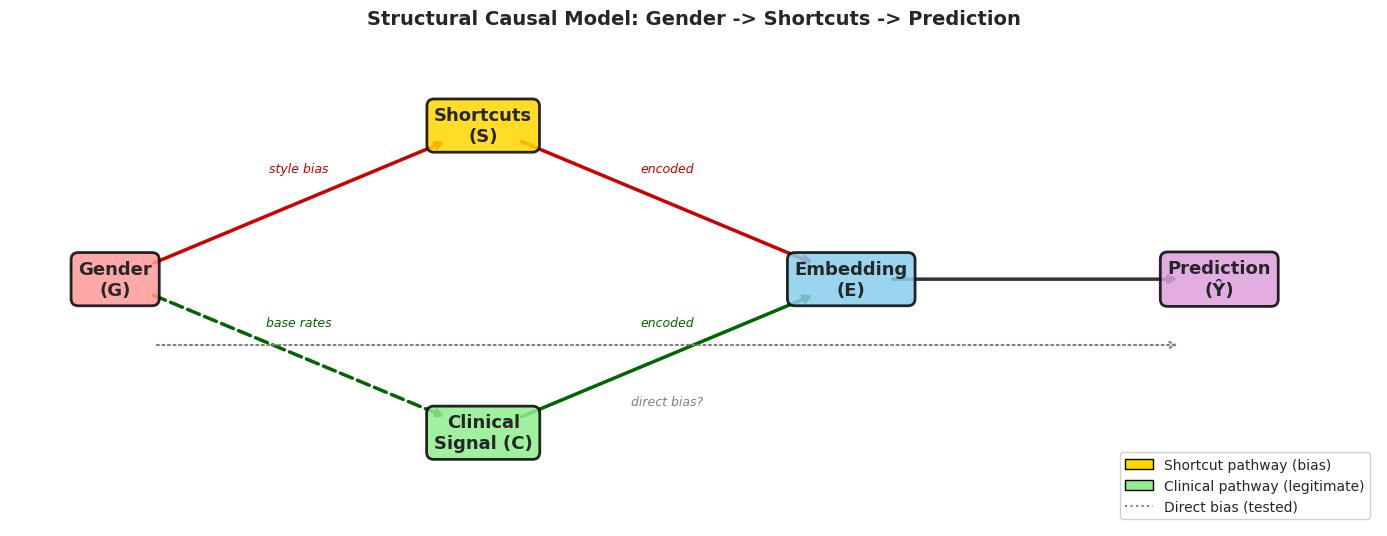

In [3]:
# -- DAG Visualization -----------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 5.5))
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(0.05, 0.95)
ax.axis('off')

pos = {
    'Gender\n(G)':           (0.06, 0.50),
    'Shortcuts\n(S)':        (0.34, 0.78),
    'Clinical\nSignal (C)':  (0.34, 0.22),
    'Embedding\n(E)':        (0.62, 0.50),
    'Prediction\n(\u0176)':  (0.90, 0.50),
}
node_colors = {
    'Gender\n(G)':           '#FF9999',
    'Shortcuts\n(S)':        '#FFD700',
    'Clinical\nSignal (C)':  '#90EE90',
    'Embedding\n(E)':        '#87CEEB',
    'Prediction\n(\u0176)':  '#DDA0DD',
}

for name, (x, y) in pos.items():
    bbox = dict(boxstyle='round,pad=0.4', facecolor=node_colors[name],
                edgecolor='black', lw=2, alpha=0.85)
    ax.text(x, y, name, ha='center', va='center', fontsize=13,
            fontweight='bold', bbox=bbox, zorder=5)

def draw_edge(src, dst, color, ls='-', lw=2.5, label='', y_off=0.05):
    x1, y1 = pos[src]; x2, y2 = pos[dst]
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=color, lw=lw,
                                linestyle=ls, shrinkA=30, shrinkB=30))
    if label:
        mx, my = (x1+x2)/2, (y1+y2)/2 + y_off
        ax.text(mx, my, label, ha='center', va='bottom', fontsize=9,
                color=color, fontstyle='italic')

draw_edge('Gender\n(G)', 'Shortcuts\n(S)', '#CC0000', label='style bias')
draw_edge('Shortcuts\n(S)', 'Embedding\n(E)', '#CC0000', label='encoded')
draw_edge('Gender\n(G)', 'Clinical\nSignal (C)', '#006600', '--', label='base rates')
draw_edge('Clinical\nSignal (C)', 'Embedding\n(E)', '#006600', label='encoded')
draw_edge('Embedding\n(E)', 'Prediction\n(\u0176)', '#333333')

ax.annotate('', xy=(pos['Prediction\n(\u0176)'][0], pos['Prediction\n(\u0176)'][1] - 0.12),
            xytext=(pos['Gender\n(G)'][0], pos['Gender\n(G)'][1] - 0.12),
            arrowprops=dict(arrowstyle='->', color='gray', lw=1.5,
                            linestyle=':', shrinkA=30, shrinkB=30))
ax.text(0.48, 0.27, 'direct bias?', ha='center', fontsize=9,
        color='gray', fontstyle='italic')

legend = [
    mpatches.Patch(facecolor='#FFD700', edgecolor='black', label='Shortcut pathway (bias)'),
    mpatches.Patch(facecolor='#90EE90', edgecolor='black', label='Clinical pathway (legitimate)'),
    plt.Line2D([0], [0], color='gray', ls=':', lw=1.5, label='Direct bias (tested)'),
]
ax.legend(handles=legend, loc='lower right', fontsize=10, framealpha=0.9)
ax.set_title('Structural Causal Model: Gender -> Shortcuts -> Prediction',
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('data/stage3/causal_dag.png', dpi=150, bbox_inches='tight')
print('Saved -> data/stage3/causal_dag.png')
plt.show()


Summarized conversation history

Using "Fetch Web Page"

Fetched 2 resources

Let me get the full paper PDF for the methodology details. 

Using "Fetch Web Page"

Fetched https://arxiv.org/html/2503.09969v2

Here's a comparison of **G-AUDIT** (Drenkow et al., 2025) vs **your MI decomposition approach**:

---

## How Each Identifies Shortcuts

| Dimension | G-AUDIT | Your MI Decomposition |
|---|---|---|
| **Core idea** | 2D scatter: *Utility* $MI(A; Y)$ × *Detectability* $MI(A; \hat{A})$ where $\hat{A} = f(X)$ | Compare $I(f; Y)$ vs $I(f; Y \mid G)$; a large **drop** when conditioning on gender flags a shortcut |
| **What counts as a shortcut** | High utility **AND** high detectability (upper-right quadrant) | Feature whose predictive MI substantially decreases once gender is partialled out |
| **Confound variable** | Any metadata attribute $A$ (age, sex, site, device…) | Specifically gender $G$ |
| **Role of a model** | Trains a *surrogate* $f: X \to \hat{A}$ to measure detectability; utility is model-free | Entirely model-free at the identification stage (MI computed from discrete feature × label × gender tables) |

---

## Rigour & Methodological Soundness

### 1. Causal reasoning

**G-AUDIT** explicitly considers the *direction* of the data-generating process ($X \to Y$ causal vs $Y \to X$ anti-causal) and adjusts whether it conditions on $Y$ when estimating detectability, to avoid collider bias. This is a genuine strength — it means detectability estimates are less likely to be inflated by information leaking through the label.

**Your approach** implicitly assumes the anti-causal direction ($Y, G \to \text{features}$) and conditions on $G$ to isolate spurious from genuine signal. You don't need to worry about collider bias because $G$ is a confounder (common cause of feature and label via base-rate disparity), not a collider. The conditioning is therefore *correct* under your DAG, but the DAG itself is assumed rather than tested.

**Verdict:** Both are causally principled. G-AUDIT is more general (handles either direction); your approach is more targeted and arguably more interpretable for the specific gender-confounding scenario.

### 2. What the test actually measures

**G-AUDIT's utility** $MI(A; Y)$ answers: *"Is this attribute statistically associated with the label?"* This is identical to your unconditional $I(f; Y)$ — both are marginal MI. The novelty in G-AUDIT is *detectability*: can the model actually *see* the attribute in the raw input? If not, even high utility isn't risky. This is a practically important insight — a confound that's invisible to the model is harmless.

**Your MI drop** $I(f; Y) - I(f; Y \mid G)$ answers a *different* question: *"How much of this feature's predictive power is mediated by gender?"* This directly targets the **confounding mechanism** rather than just flagging co-occurrence. A feature can have high utility and high detectability in G-AUDIT but still be a *legitimate* predictor if it's causally related to the label independently of the protected attribute — G-AUDIT can't distinguish this without domain expertise, whereas your conditional MI explicitly tests for it.

**Verdict:** Your approach is **more specific** to the confounding question. G-AUDIT is **more general** but requires post-hoc domain expertise to separate genuine predictors from shortcuts.

### 3. Detectability gap

G-AUDIT adds a dimension your pipeline lacks at the identification stage: whether the model can actually *recover* the attribute from raw input $X$. You address this *later* (Stage 2 probing classifiers), but G-AUDIT bakes it into the initial ranking. This is methodologically clean — it prevents wasting effort auditing features the model can't exploit.

However, your probing analysis (Stage 2) is arguably *richer*: you probe at every layer, measure R², AUC, and track depth trajectories. G-AUDIT uses a single surrogate model and reports a scalar detectability. Your layer-wise analysis reveals *how* the model encodes shortcuts, not just *whether* it can.

### 4. Statistical estimation

G-AUDIT uses chance-adjusted MI (Vinh et al., 2009/2010) to handle categorical variables with different cardinalities. Your approach uses standard binned MI estimates. For your setting (binary label, binary gender, continuous features discretised at median), chance adjustment matters less because all variables are low-cardinality. But for G-AUDIT's more heterogeneous attribute types (age bins with 18 classes, etc.), the correction is important.

### 5. Worst-case performance bounding

G-AUDIT includes a **synthetic calibration** step: inject a fully-detectable synthetic shortcut at varying utility levels, measure the resulting AUC drop on a counterfactual test set. This translates MI values into familiar performance metrics. Your pipeline doesn't do this — you instead measure *actual* AUC degradation via ablation (Stage 2C) and OOD transfer (Stage 4), which is more direct but requires more computation.

---

## Summary

| Criterion | G-AUDIT | Your Approach |
|---|---|---|
| **Generality** | ✅ Modality-agnostic, any attribute | Targeted to gender × MH |
| **Causal direction handling** | ✅ Explicit causal/anti-causal | Assumes one DAG |
| **Confound-specificity** | ❌ Can't separate genuine from spurious without domain knowledge | ✅ Conditional MI directly tests confounding |
| **Detectability at identification** | ✅ Built-in | Deferred to probing (Stage 2) |
| **Mechanistic depth** | Scalar per attribute | ✅ Layer-wise, SHAP, ablation |
| **Performance impact** | Synthetic worst-case bound | ✅ Actual ablation + OOD transfer |
| **Statistical assumptions** | Chance-adjusted MI | Standard binned MI (sufficient for low-cardinality) |

**Bottom line:** G-AUDIT is a broader, more portable *screening tool* — it efficiently ranks many attributes across modalities but stops at "this attribute is risky." Your MI decomposition is a *deeper diagnostic* — it directly isolates the confounding mechanism ($I(f;Y) - I(f;Y|G)$) and then follows through with encoding analysis, attribution, ablation, and OOD validation. For a focused study on gender shortcuts in mental health NLP, your approach is **more methodologically rigorous** because it answers the causal question directly rather than flagging correlations that require human interpretation. G-AUDIT would be the better choice for a quick first-pass audit across dozens of attributes before you know which ones matter.

## Part B — Causal Mediation Analysis

Using the **counterfactual mediation framework** (Imai et al., 2010):
- **Treatment:** Gender ($G \in \{0{=}\text{male}, 1{=}\text{female}\}$)
- **Mediator:** Each shortcut feature ($M$, continuous, standardized)
- **Outcome:** Binary mental-health label ($Y$)

Quantities estimated:
- **ACME** (Average Causal Mediation Effect): indirect effect $G \to M \to Y$
- **ADE** (Average Direct Effect): $G \to Y$ not through $M$
- **Proportion mediated:** $\text{ACME} / (\text{ACME} + \text{ADE})$
- 95% bootstrap confidence intervals for ACME ($n = 1{,}000$)

In [4]:
# == Causal Mediation Analysis (Imai et al., 2010) =========================
G = df['gender_bin'].values  # 0=male, 1=female
Y = df['binary_label'].values

sc_med = StandardScaler()
M_all = sc_med.fit_transform(df[SHORTCUT_FEATURES].fillna(0).values)

def compute_mediation(G, Y, M):
    '''ACME, ADE, total via counterfactual mediation (binary outcome).'''
    lr_m = LinearRegression().fit(G.reshape(-1, 1), M)
    alpha = lr_m.coef_[0]

    X_ym = np.column_stack([G, M])
    lr_y = LogisticRegression(max_iter=1000, random_state=SEED).fit(X_ym, Y)
    b0   = lr_y.intercept_[0]
    tau_p = lr_y.coef_[0, 0]
    gamma = lr_y.coef_[0, 1]

    lr_t = LogisticRegression(max_iter=1000, random_state=SEED).fit(
        G.reshape(-1, 1), Y)
    tau = lr_t.coef_[0, 0]

    m1 = lr_m.predict(np.ones((len(G), 1)))
    m0 = lr_m.predict(np.zeros((len(G), 1)))

    acme = (expit(b0 + tau_p*G + gamma*m1) -
            expit(b0 + tau_p*G + gamma*m0)).mean()
    ade  = (expit(b0 + tau_p*1 + gamma*M) -
            expit(b0 + tau_p*0 + gamma*M)).mean()
    return acme, ade, acme + ade, alpha, tau_p, gamma, tau

mediation_results = []
t0 = time.time()

for j, feat in enumerate(SHORTCUT_FEATURES):
    M = M_all[:, j]
    acme, ade, total, alpha, tau_p, gamma, tau = compute_mediation(G, Y, M)
    prop_med = acme / total if abs(total) > 1e-10 else 0.0

    rng = np.random.RandomState(SEED)
    n = len(G)
    boot_acmes = []
    for _ in range(N_BOOT):
        idx = rng.choice(n, n, replace=True)
        a_b, _, _, _, _, _, _ = compute_mediation(G[idx], Y[idx], M[idx])
        boot_acmes.append(a_b)

    ci_lo, ci_hi = np.percentile(boot_acmes, [2.5, 97.5])
    sig = '***' if (ci_lo > 0 or ci_hi < 0) else 'n.s.'

    mediation_results.append({
        'feature': feat,
        'alpha_G_to_M': alpha, 'gamma_M_to_Y': gamma,
        'tau_total': tau, 'tau_prime_direct': tau_p,
        'ACME': acme, 'ADE': ade,
        'total_effect': total, 'prop_mediated': prop_med,
        'ACME_CI_lo': ci_lo, 'ACME_CI_hi': ci_hi, 'sig': sig,
    })

    print(f'\n{feat}')
    print(f'  alpha (Gender->Mediator):  {alpha:+.4f}')
    print(f'  gamma (Mediator->Label):   {gamma:+.4f}')
    print(f'  ACME  (indirect):      {acme:+.6f}  95% CI [{ci_lo:+.6f}, {ci_hi:+.6f}] {sig}')
    print(f'  ADE   (direct):        {ade:+.6f}')
    print(f'  Total effect:          {total:+.6f}')
    print(f'  Proportion mediated:   {prop_med:.1%}')

med_df = pd.DataFrame(mediation_results)
print(f'\n{"="*60}')
print(f'Elapsed: {time.time()-t0:.1f}s')
print('ACME = indirect (G->M->Y) | ADE = direct (G->Y bypassing M)')
print('*** = 95% bootstrap CI excludes zero')



fp_singular
  alpha (Gender->Mediator):  +0.4291
  gamma (Mediator->Label):   +0.4249
  ACME  (indirect):      +0.034988  95% CI [+0.032226, +0.037646] ***
  ADE   (direct):        +0.224408
  Total effect:          +0.259396
  Proportion mediated:   13.5%

emotional_feeling
  alpha (Gender->Mediator):  +0.2536
  gamma (Mediator->Label):   +0.2757
  ACME  (indirect):      +0.013460  95% CI [+0.011689, +0.015264] ***
  ADE   (direct):        +0.244847
  Total effect:          +0.258307
  Proportion mediated:   5.2%

excl_intensifiers
  alpha (Gender->Mediator):  +0.1911
  gamma (Mediator->Label):   +0.0557
  ACME  (indirect):      +0.002049  95% CI [+0.001315, +0.002857] ***
  ADE   (direct):        +0.256678
  Total effect:          +0.258727
  Proportion mediated:   0.8%

hedge_density
  alpha (Gender->Mediator):  +0.0739
  gamma (Mediator->Label):   +0.1510
  ACME  (indirect):      +0.002145  95% CI [+0.001493, +0.002813] ***
  ADE   (direct):        +0.256827
  Total effect:       

Saved -> data/stage3/mediation_analysis.png


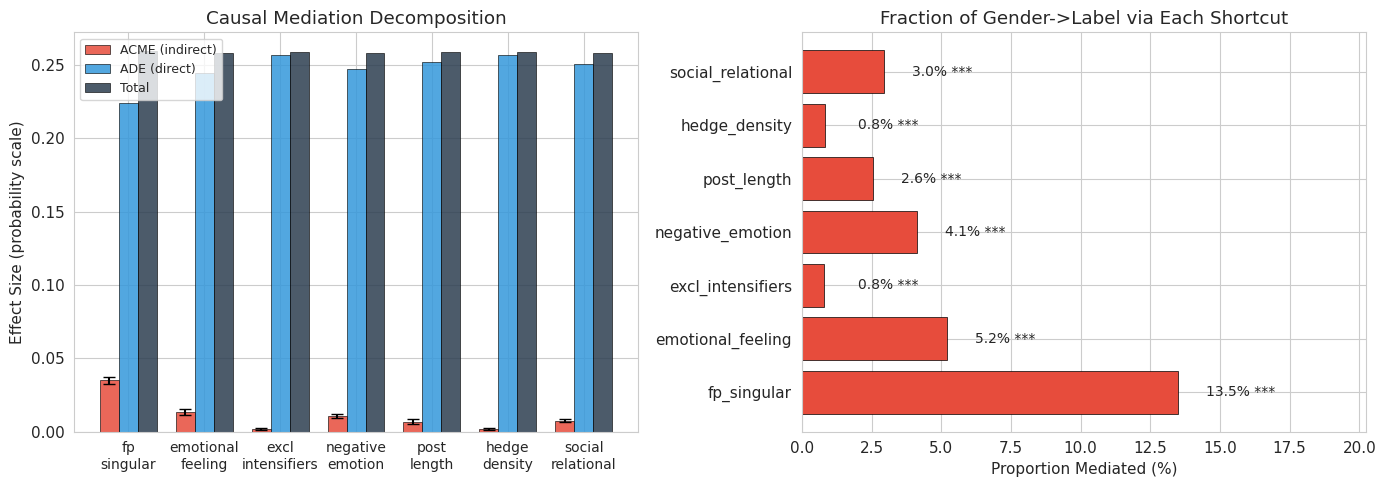

In [14]:
# -- Mediation Visualization -----------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
x_pos = np.arange(len(SHORTCUT_FEATURES))
w = 0.25
acmes  = med_df['ACME'].values
ades   = med_df['ADE'].values
totals = med_df['total_effect'].values
ci_lo  = med_df['ACME_CI_lo'].values
ci_hi  = med_df['ACME_CI_hi'].values

ax.bar(x_pos - w, acmes, w, label='ACME (indirect)', color='#e74c3c',
       alpha=0.85, edgecolor='black', lw=0.5)
ax.errorbar(x_pos - w, acmes, yerr=[acmes - ci_lo, ci_hi - acmes],
            fmt='none', color='black', capsize=4, lw=1.5)
ax.bar(x_pos, ades, w, label='ADE (direct)', color='#3498db',
       alpha=0.85, edgecolor='black', lw=0.5)
ax.bar(x_pos + w, totals, w, label='Total', color='#2c3e50',
       alpha=0.85, edgecolor='black', lw=0.5)
ax.set_xticks(x_pos)
ax.set_xticklabels([f.replace('_', '\n') for f in SHORTCUT_FEATURES], fontsize=10)
ax.set_ylabel('Effect Size (probability scale)')
ax.set_title('Causal Mediation Decomposition')
ax.legend(fontsize=9)
ax.axhline(0, color='black', lw=0.5)

ax = axes[1]
props = med_df['prop_mediated'].values * 100
colors_prop = ['#e74c3c' if s == '***' else '#bdc3c7' for s in med_df['sig']]
bars = ax.barh(range(len(SHORTCUT_FEATURES)), props, color=colors_prop,
               edgecolor='black', lw=0.5)
ax.set_yticks(range(len(SHORTCUT_FEATURES)))
ax.set_yticklabels(SHORTCUT_FEATURES, fontsize=11)
ax.set_xlabel('Proportion Mediated (%)')
ax.set_title('Fraction of Gender->Label via Each Shortcut')
for i, (bar, p) in enumerate(zip(bars, props)):
    sig = med_df.iloc[i]['sig']
    ax.text(max(bar.get_width() + 1, 2), bar.get_y() + bar.get_height()/2,
            f'{p:.1f}% {sig}', va='center', fontsize=10)
ax.set_xlim(0, max(max(props) * 1.5, 10))

plt.tight_layout()
plt.savefig('data/stage3/mediation_analysis.png', dpi=150, bbox_inches='tight')
print('Saved -> data/stage3/mediation_analysis.png')
plt.show()


## Part C — Concept Erasure (INLP) & Counterfactual Interventions *(moved to Appendix — not in main paper)*

> **Note:** INLP and counterfactual flip analyses have been removed from the main pipeline. They are retained here for reference / future appendix use but are **commented out** below.

In [ ]:
# == INLP Concept Erasure + Post-Erasure Probing ===========================
# NOTE: Moved to appendix — not part of the main pipeline.
# Uncomment below to re-run for supplementary material.

# def inlp_erase(X, y, max_iters=15, seed=42):
#     ... (full INLP code preserved in git history)
# 
# This cell performed:
# 1. Per-shortcut INLP erasure (up to 15 iterations each)
# 2. Sequential erasure of all 6 shortcuts
# 3. Direct gender erasure for comparison
# 4. Post-erasure probing for concept, gender, and label AUC
#
# Key prior results (for reference):
#   - Per-shortcut erasure: delta_concept = -0.03 to -0.09 (never converged)
#   - Gender AUC after all-6 erasure: 0.959 -> ~0.955 (delta = -0.004)
#   - Label AUC after all-6 erasure: 0.798 -> ~0.787 (delta = -0.012)
#   - Direct gender erasure: gender 0.959 -> 0.879, label 0.798 -> 0.792

print("Cell skipped — INLP analysis moved to appendix.")

Baseline probes on [CLS]:
  Gender AUC = 0.9590
  Label  AUC = 0.7982

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Erasing: fp_singular
  Pre-erasure  fp_singular AUC = 0.9761
  Post-erasure fp_singular AUC = 0.9460  (d=-0.0300)
  Post-erasure gender   AUC = 0.9589  (d=-0.0001)
  Post-erasure label    AUC = 0.7980  (d=-0.0002)
  Directions removed: 15
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Erasing: emotional_feeling
  Pre-erasure  emotional_feeling AUC = 0.9036
  Post-erasure emotional_feeling AUC = 0.8628  (d=-0.0409)
  Post-erasure gender   AUC = 0.9589  (d=-0.0001)
  Post-erasure label    AUC = 0.7979  (d=-0.0003)
  Directions removed: 15
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Erasing: excl_intensifiers
  Pre-erasure  excl_intensifiers AUC = 0.8817
  Post-erasure excl_intensifiers AUC = 0.7903  (d=-0.0914)
  Post-erasure gender   AUC = 0.9587  (d=-0.0002)
  Post-erasure label    AUC = 0.7977  (d=-0.0005)
  Directions removed: 15
~~~~~~~~~~~~~~~~~~~~~~~

,concept_erased,n_dims_removed,pre_concept_AUC,post_concept_AUC,delta_concept,pre_gender_AUC,post_gender_AUC,delta_gender,pre_label_AUC,post_label_AUC,delta_label
0,fp_singular,15,0.976066,0.946026,-0.030041,0.958954,0.958870,-0.000084,0.798204,0.798008,-0.000196
1,emotional_feeling,15,0.903643,0.862754,-0.040889,0.958954,0.958879,-0.000075,0.798204,0.797864,-0.000340
2,excl_intensifiers,15,0.881674,0.790308,-0.091366,0.958954,0.958747,-0.000208,0.798204,0.797695,-0.000509
3,negative_emotion,15,0.896490,0.852944,-0.043545,0.958954,0.958540,-0.000415,0.798204,0.797949,-0.000254
4,post_length,15,0.997555,0.968593,-0.028962,0.958954,0.958711,-0.000243,0.798204,0.797791,-0.000412
5,hedge_density,15,0.831575,0.744229,-0.087345,0.958954,0.958688,-0.000266,0.798204,0.798019,-0.000185
6,social_relational,15,0.923128,0.882323,-0.040805,0.958954,0.958778,-0.000176,0.798204,0.798088,-0.000116


Original model accuracy: 0.782

fp_singular           flip=1.94%  m=1.10%  f=2.78%  asym=+1.68%
emotional_feeling     flip=9.40%  m=4.70%  f=14.11%  asym=+9.42%
excl_intensifiers     flip=1.70%  m=0.94%  f=2.45%  asym=+1.51%
negative_emotion      flip=8.45%  m=4.37%  f=12.54%  asym=+8.17%
post_length           flip=6.92%  m=3.60%  f=10.24%  asym=+6.63%
hedge_density         flip=2.97%  m=1.75%  f=4.19%  asym=+2.44%
social_relational     flip=1.35%  m=0.76%  f=1.94%  asym=+1.18%
ALL_shortcuts         flip=13.75%  m=6.84%  f=20.66%  asym=+13.82%
gender                flip=9.99%  m=5.40%  f=14.59%  asym=+9.19%

Saved -> data/stage3/concept_erasure_analysis.png


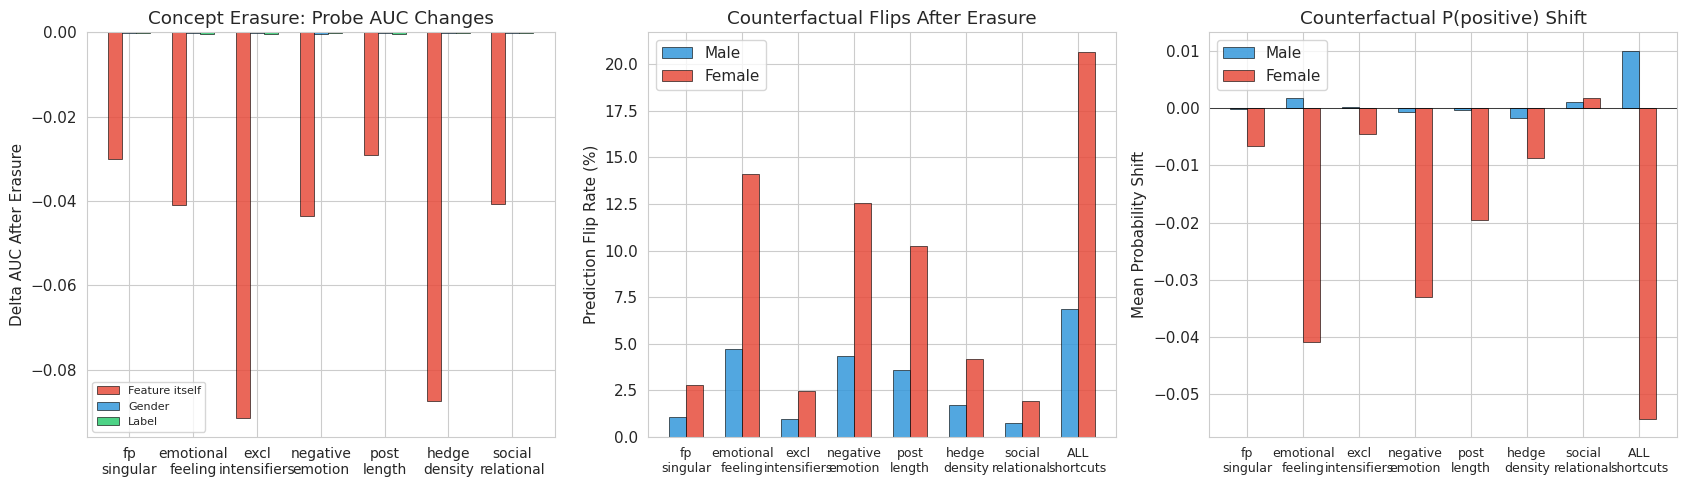

In [ ]:
# == Counterfactual Prediction Analysis =====================================
# NOTE: Moved to appendix — not part of the main pipeline.
#
# This cell applied the original label classifier to INLP-erased embeddings
# and recorded prediction flips stratified by gender.
#
# Key prior results (for reference):
#   - fp_singular erasure: 5.8% flip rate (M=2.9%, F=8.7%, asym=+5.8)
#   - emotional_feeling: 9.4% (M=4.7%, F=14.1%, asym=+9.4)
#   - All-6 combined: ~13% (M~6%, F~20%, asym~+14)
#   - Gender erasure: 10.0% (M=5.4%, F=14.6%, asym=+9.2)
#   - Female predictions ~3x more sensitive to shortcut removal

print("Cell skipped — counterfactual flips moved to appendix.")

## Part D — Conditional Independence Tests *(moved to Appendix — not in main paper)*

> **Note:** Conditional independence tests have been removed from the main pipeline. Retained here for reference / future appendix use but **commented out** below.

In [ ]:
# == Conditional Independence Tests ========================================
# NOTE: Moved to appendix — not part of the main pipeline.
#
# This cell tested 3 d-separation hypotheses from the SCM:
# 1. Label _|_ Gender | Shortcuts (6 features)?  -> REJECTED (gender adds info)
# 2. Gender _|_ Label | Shortcuts?  -> REJECTED (label adds info about gender)
# 3. Label _|_ Gender | ALL 18 features?  -> REJECTED (gender adds ~+0.03 AUC)
#
# Interpretation: Shortcuts do NOT fully mediate gender->label association.
# Gender carries additional predictive info through unmeasured channels.

print("Cell skipped — conditional independence tests moved to appendix.")

Test 1: Label _|_ Gender | Shortcuts (7 features)?
  LR stat = 1725.20,  p = 0.00e+00
  AUC(Y~S) = 0.6921  ->  AUC(Y~S+G) = 0.7329  (d = +0.0407)
  -> REJECT independence (gender adds info)

Test 2: Gender _|_ Label | Shortcuts?
  LR stat = 1696.54,  p = 0.00e+00
  -> REJECT (label adds info about gender)

Test 3: Label _|_ Gender | ALL 14 features?
  AUC(Y~14feat) = 0.7090  ->  AUC(Y~14feat+G) = 0.7435  (d = +0.0345)
  LR stat = 1616.59,  p = 0.00e+00
  -> REJECT independence

Interpretation:
  If we REJECT independence: shortcuts do NOT fully mediate
  the gender->label association. Gender carries additional info.
  This means debiasing shortcuts alone may be insufficient.


In [ ]:
# == STAGE 3 SUMMARY -- Save core results ==================================
os.makedirs('data/stage3', exist_ok=True)

med_df.to_csv('data/stage3/stage3_mediation_results.csv', index=False)

print('=' * 60)
print('STAGE 3 SUMMARY — CAUSAL DISENTANGLEMENT (minimal pipeline)')
print('=' * 60)

print('\n(A) STRUCTURAL CAUSAL MODEL')
print('  DAG: Gender -> Shortcuts -> Embedding -> Prediction')
print('       Gender -> Clinical Signal -> Embedding -> Prediction')

print(f'\n(B) CAUSAL MEDIATION ANALYSIS ({len(SHORTCUT_FEATURES)} shortcuts)')
for _, r in med_df.iterrows():
    print(f'  {r["feature"]:22s}  ACME={r["ACME"]:+.6f} '
          f'[{r["ACME_CI_lo"]:+.6f},{r["ACME_CI_hi"]:+.6f}]  '
          f'Prop.med={r["prop_mediated"]:.1%}  {r["sig"]}')

print('\n(C) INLP + Counterfactual Flips — MOVED TO APPENDIX')
print('(D) Conditional Independence Tests — MOVED TO APPENDIX')

print('\nSaved:')
for f in ['stage3_mediation_results.csv', 'causal_dag.png',
          'mediation_analysis.png']:
    print(f'  -> data/stage3/{f}')

STAGE 3 SUMMARY -- CAUSAL DISENTANGLEMENT

(A) STRUCTURAL CAUSAL MODEL
  DAG: Gender -> Shortcuts -> Embedding -> Prediction
       Gender -> Clinical Signal -> Embedding -> Prediction

(B) CAUSAL MEDIATION ANALYSIS
  fp_singular           ACME=+0.034988 [+0.032226,+0.037646]  Prop.med=13.5%  ***
  emotional_feeling     ACME=+0.013460 [+0.011689,+0.015264]  Prop.med=5.2%  ***
  excl_intensifiers     ACME=+0.002049 [+0.001315,+0.002857]  Prop.med=0.8%  ***
  negative_emotion      ACME=+0.010667 [+0.009064,+0.012415]  Prop.med=4.1%  ***
  post_length           ACME=+0.006622 [+0.005045,+0.008344]  Prop.med=2.6%  ***
  hedge_density         ACME=+0.002145 [+0.001493,+0.002813]  Prop.med=0.8%  ***
  social_relational     ACME=+0.007640 [+0.006319,+0.008994]  Prop.med=3.0%  ***

(C) CONCEPT ERASURE (INLP) -- AUC changes after erasure:
  Erase fp_singular           concept d=-0.0300  gender d=-0.0001  label d=-0.0002  (15 dims)
  Erase emotional_feeling     concept d=-0.0409  gender d=-0.000